# 02 - Demographics Analysis

Analyze student demographics: age, gender, grade distribution.

In [1]:
import sys
sys.path.insert(0, '../scripts')
from helpers import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load and clean data
df = load_survey_data()
df = clean_survey_data(df)
print(f"Loaded {len(df)} survey responses")

Loaded 366 survey responses


In [3]:
# Demographics summary
get_demographics_summary(df)

SURVEY DEMOGRAPHICS SUMMARY
Total Responses: 366

Age Range: 14 - 60
Average Age: 33.5

Gender Distribution:
gender
Female            140
Male              139
Prefer Not Say     87
Name: count, dtype: int64

Grade/Class Distribution:
grade/class
Under-Grad (Bachelors)    69
12                        63
11                        62
Post-grad (Masters)       58
10                        57
9                         57
Name: count, dtype: int64


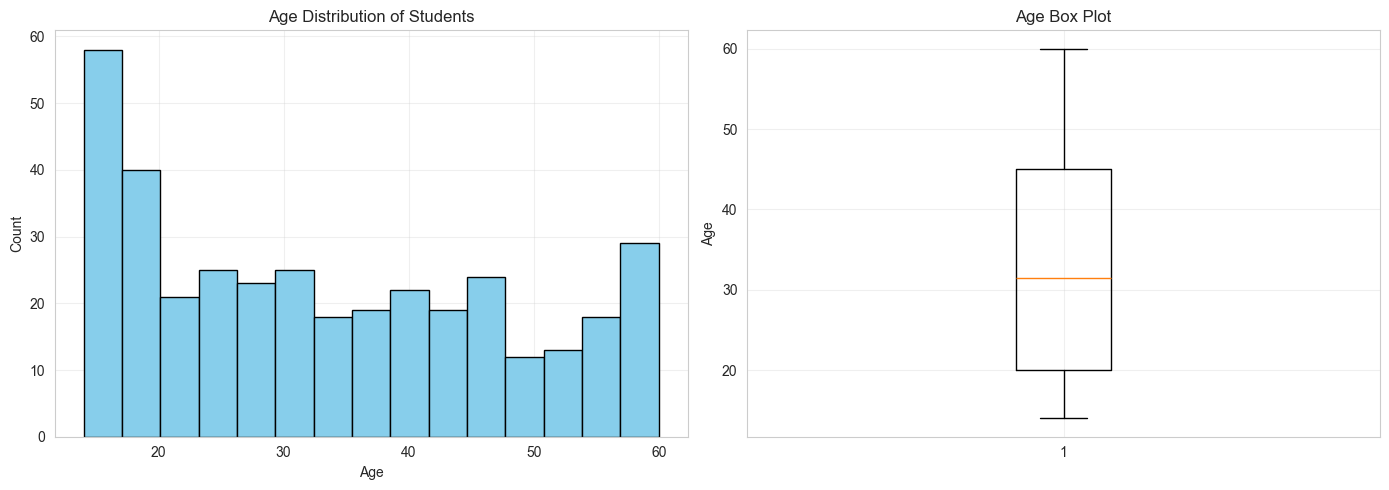

In [4]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['age'].dropna(), bins=15, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution of Students')
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(df['age'].dropna())
axes[1].set_ylabel('Age')
axes[1].set_title('Age Box Plot')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

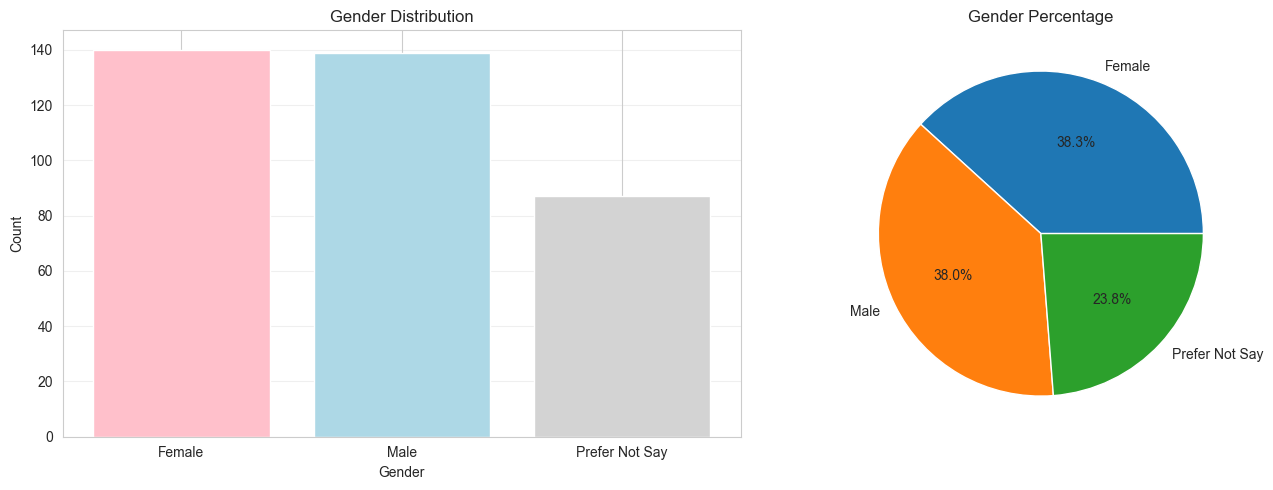

In [5]:
# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
gender_counts = df['gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['pink', 'lightblue', 'lightgray'][:len(gender_counts)])
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].set_title('Gender Distribution')
axes[0].grid(alpha=0.3, axis='y')

# Pie chart
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
axes[1].set_title('Gender Percentage')

plt.tight_layout()
plt.show()

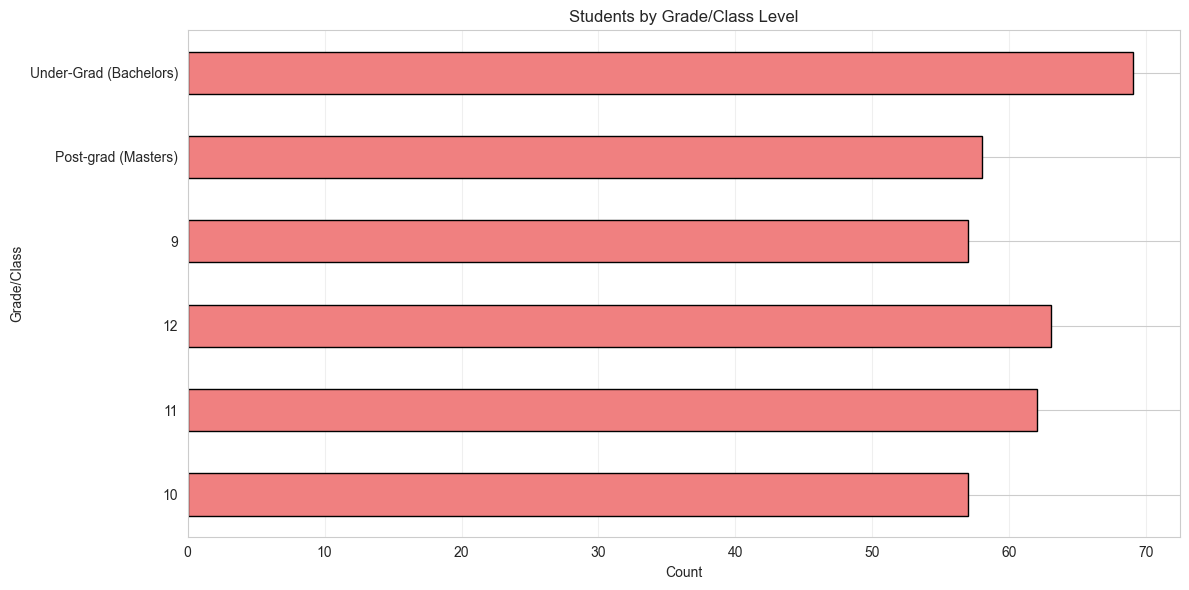

In [6]:
# Grade/Class distribution
fig, ax = plt.subplots(figsize=(12, 6))
grade_counts = df['grade/class'].value_counts().sort_index()
grade_counts.plot(kind='barh', color='lightcoral', edgecolor='black')
ax.set_xlabel('Count')
ax.set_ylabel('Grade/Class')
ax.set_title('Students by Grade/Class Level')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

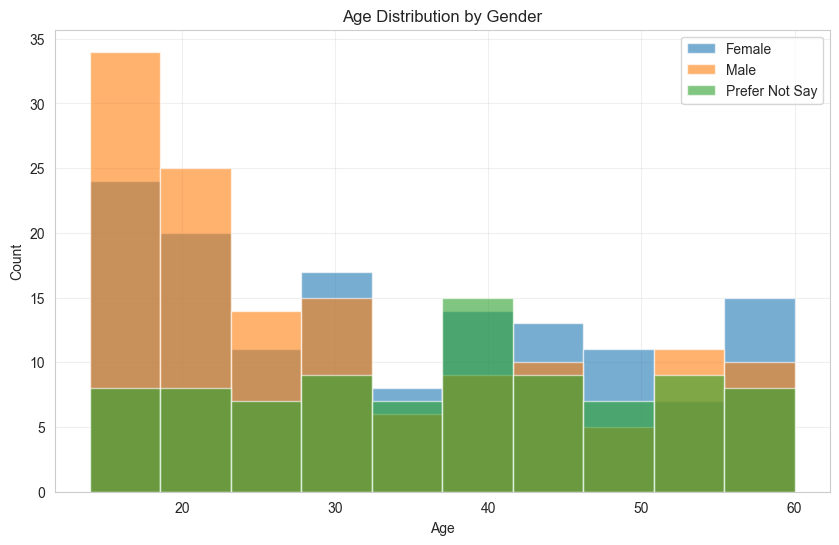

In [7]:
# Age distribution by gender
plt.figure(figsize=(10, 6))
for gender in df['gender'].unique():
    if pd.notna(gender):
        ages = df[df['gender'] == gender]['age'].dropna()
        plt.hist(ages, alpha=0.6, label=str(gender), bins=10)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution by Gender')
plt.legend()
plt.grid(alpha=0.3)
plt.show()